In [1]:
import os
from deepface import DeepFace
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle

2025-06-13 10:40:31.489346: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-13 10:40:31.491639: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-13 10:40:31.570234: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-13 10:40:31.571921: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-13 10:40:32.383123: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [2]:
model_name = "Facenet512"

# What Is An Embedding?

An embedding is multi-dimensional vector, but it is not understandable as is for human beings

In [13]:
embedding = DeepFace.represent(img_path="dataset/img1.jpg", model_name=model_name, detector_backend="mtcnn")[0]["embedding"]

2025-06-13 10:44:26.488333: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:f3:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-13 10:44:26.488751: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [14]:
print(f"Embedding has {len(embedding)} dimensions")

Embedding has 512 dimensions


In [16]:
# seems like a random number but it is understandable by computers
embedding

[-0.5800899863243103,
 0.49073147773742676,
 -0.541978120803833,
 -0.5362149477005005,
 0.8673033118247986,
 -0.3110777735710144,
 1.6439862251281738,
 1.0422444343566895,
 0.49424535036087036,
 -0.7632251381874084,
 0.568842887878418,
 1.2297348976135254,
 0.4075915217399597,
 -1.9624804258346558,
 -1.8717180490493774,
 0.1243176981806755,
 -0.029327712953090668,
 -0.16930146515369415,
 -0.6892706155776978,
 -1.229070782661438,
 -0.2585531771183014,
 0.7143777012825012,
 -1.39646315574646,
 -0.3089902698993683,
 -0.2544291019439697,
 0.8497409224510193,
 0.22358675301074982,
 -1.6465028524398804,
 -1.1567769050598145,
 0.10510019212961197,
 0.23702986538410187,
 -0.7497061491012573,
 1.7056957483291626,
 -0.7189028859138489,
 -0.008875804953277111,
 0.5017907023429871,
 0.7206048369407654,
 -0.7071428298950195,
 0.7452940344810486,
 -0.47018516063690186,
 0.33446836471557617,
 -2.702781915664673,
 0.4717637300491333,
 -0.6417455673217773,
 -1.26873779296875,
 0.566139280796051,
 -1.20

# Visualizing Embeddings in 2D Space

If we visualize multi-dimensional vectors onto 2D or 3D space, then we will be able to visualize them

In [ ]:
# unit test items of deepface
database = {
    "angelina_jolie": [
        "dataset/img1.jpg",
        "dataset/img2.jpg",
        "dataset/img4.jpg",
        "dataset/img5.jpg",
        "dataset/img6.jpg",
        "dataset/img7.jpg",
        # "dataset/img8.jpg",
        "dataset/img10.jpg",
        "dataset/img11.jpg",
    ],
    "jennifer_aniston": [
        "dataset/img3.jpg",
        "dataset/img12.jpg",
        "dataset/img53.jpg",
        "dataset/img54.jpg",
        "dataset/img55.jpg",
        "dataset/img56.jpg",
    ],
    "scarlett_johansson": [
        "dataset/img9.jpg",
        "dataset/img47.jpg",
        "dataset/img48.jpg",
        "dataset/img49.jpg",
        "dataset/img50.jpg",
        "dataset/img51.jpg",
    ],
    "mark_zuckerberg": [
        "dataset/img13.jpg",
        "dataset/img14.jpg",
        "dataset/img15.jpg",
        "dataset/img57.jpg",
        "dataset/img58.jpg",
    ],
    "jack_dorsey": [
        "dataset/img16.jpg",
        "dataset/img17.jpg",
        "dataset/img59.jpg",
        "dataset/img61.jpg",
        "dataset/img62.jpg",
    ],
    "elon_musk": [
        "dataset/img18.jpg",
        "dataset/img19.jpg",
        "dataset/img67.jpg",
    ],
    # "jeff_bezos": [
    #     "dataset/img20.jpg",
    #     "dataset/img21.jpg",
    # ],
    "marissa_mayer": [
        "dataset/img22.jpg",
        "dataset/img23.jpg",
    ],
    "sundar_pichai": [
        "dataset/img24.jpg",
        "dataset/img25.jpg",
    ],
    "katty_perry": [
        "dataset/img26.jpg",
        "dataset/img27.jpg",
        "dataset/img28.jpg",
        "dataset/img42.jpg",
        "dataset/img43.jpg",
        "dataset/img44.jpg",
        "dataset/img45.jpg",
        "dataset/img46.jpg",
    ],
    "matt_damon": [
        "dataset/img29.jpg",
        "dataset/img30.jpg",
        "dataset/img31.jpg",
        "dataset/img32.jpg",
        "dataset/img33.jpg",
    ],
    "leonardo_dicaprio": [
        "dataset/img34.jpg",
        "dataset/img35.jpg",
        "dataset/img36.jpg",
        "dataset/img37.jpg",
    ],
    "george_clooney": [
        "dataset/img38.jpg",
        "dataset/img39.jpg",
        "dataset/img40.jpg",
        "dataset/img41.jpg",
    ],
}

In [4]:
items = 0
for identity, images in database.items():
    items += len(images)

In [5]:
print(f"there are {len(database)} identities with {items} imaged in the database")

there are 12 identities with 58 imaged in the database


In [6]:
target_file = f"facial_database_{model_name}.pkl"

if os.path.exists(target_file) is False:
    vector_database = {}
    for identity, images in tqdm(database.items()):
        target_embeddings = []
        for image in images:
            emb = DeepFace.represent(
                img_path=image,
                model_name=model_name,
                detector_backend="mtcnn"
            )[0]["embedding"]

            target_embeddings.append(emb)
        
        vector_database[identity] = target_embeddings

    with open(target_file, 'wb') as f:
        pickle.dump(vector_database, f)
else:
    with open(target_file, 'rb') as f:
        vector_database = pickle.load(f)

In [7]:
target_identities = []
target_embeddings = []
for identity, embeddings in vector_database.items():
    for embedding in embeddings:
        target_embeddings.append(embedding)
        target_identities.append(identity)

In [8]:
image_sources = []
for identity, images in tqdm(database.items()):
    for image in images:
        image_sources.append(image.split("/")[-1].split(".")[0])

100%|██████████| 12/12 [00:00<00:00, 70393.91it/s]


In [9]:
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(target_embeddings)

In [10]:
x, y = zip(*vectors_2d)

In [11]:
colors = [
    'red', 'blue', 'green', 'orange', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan',
    'magenta', 'gold', 'teal', 'navy', 'lime'
]

# Clusters

Embedddings of identities seem creating clusters

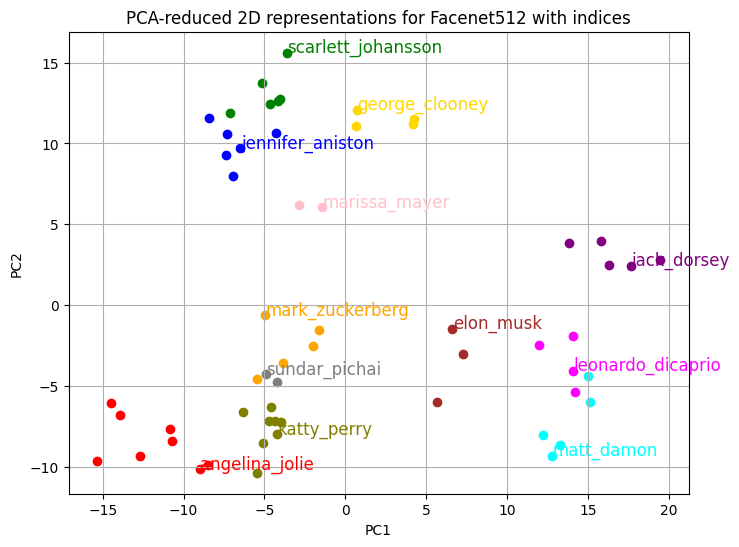

In [12]:
printed_labels = set()

plt.figure(figsize=(8, 6))
for i, (x, y) in enumerate(vectors_2d):
    target_identity = target_identities[i]

    target_idx = None
    for idx, (identity, _) in enumerate(database.items()):
        if target_identity == identity:
            target_idx = idx

    plt.scatter(x, y, color=colors[target_idx])

    # plt.text(x + 0.02, y + 0.02, image_sources[i], fontsize=12, color=colors[target_idx])
    if target_identity not in printed_labels:
        plt.text(x + 0.02, y + 0.02, target_identity, fontsize=12, color=colors[target_idx])
        printed_labels.add(target_identity)

plt.title(f"PCA-reduced 2D representations for {model_name} with indices")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()